# Spectral Autoencoder for Hyperspectral Anomaly Detection

This notebook develops a dense autoencoder for unsupervised anomaly detection in AVIRIS hyperspectral imagery.

The model learns to reconstruct hyperspectral pixel signatures. Pixels with high reconstruction error are considered potential anomalies.

In [2]:
%pip install numpy scipy pandas matplotlib scikit-learn torch joblib

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import random
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    classification_report,
    confusion_matrix
)

import torch
from torch import nn
from torch.utils.data import (
    TensorDataset,
    DataLoader,
    random_split
)

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Libraries imported successfully.


In [3]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

print("Random seed set to:", RANDOM_STATE)

Random seed set to: 42


In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device being used:", device)

Device being used: cpu


In [7]:
DATA_PATH = "/Users/monicachaganti/Desktop/hyperspectral-anomaly-detection/data/aviris_1.mat"
RESULTS_DIR = "../results"
MODELS_DIR = "../models"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("Dataset path:", DATA_PATH)
print("Results folder:", RESULTS_DIR)
print("Models folder:", MODELS_DIR)

Dataset path: /Users/monicachaganti/Desktop/hyperspectral-anomaly-detection/data/aviris_1.mat
Results folder: ../results
Models folder: ../models


In [9]:
mat_file = loadmat(DATA_PATH)

print("Variables inside the MAT file:")

for key, value in mat_file.items():
    if not key.startswith("__"):
        print(
            key,
            type(value),
            getattr(value, "shape", None)
        )

Variables inside the MAT file:
data <class 'numpy.ndarray'> (100, 100, 189)
map <class 'numpy.ndarray'> (100, 100)


In [11]:
cube = mat_file["data"].astype(np.float32)

ground_truth = np.squeeze(
    mat_file["map"]
)

ground_truth = (
    ground_truth > 0
).astype(np.uint8)

print("Hyperspectral cube shape:", cube.shape)
print("Ground-truth shape:", ground_truth.shape)
print("Ground-truth values:", np.unique(ground_truth))

Hyperspectral cube shape: (100, 100, 189)
Ground-truth shape: (100, 100)
Ground-truth values: [0 1]


In [13]:
cube = np.nan_to_num(
    cube,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

print("NaN values:", np.isnan(cube).sum())
print("Infinite values:", np.isinf(cube).sum())

NaN values: 0
Infinite values: 0


In [15]:
height, width, bands = cube.shape

print("Image height:", height)
print("Image width:", width)
print("Number of spectral bands:", bands)
print("Total number of pixels:", height * width)

Image height: 100
Image width: 100
Number of spectral bands: 189
Total number of pixels: 10000


In [17]:
number_of_anomalies = int(
    ground_truth.sum()
)

number_of_background_pixels = (
    height * width
    - number_of_anomalies
)

anomaly_percentage = (
    number_of_anomalies
    / (height * width)
) * 100

print("Background pixels:", number_of_background_pixels)
print("Anomaly pixels:", number_of_anomalies)
print(f"Anomaly percentage: {anomaly_percentage:.4f}%")

Background pixels: 9936
Anomaly pixels: 64
Anomaly percentage: 0.6400%


In [19]:
X = cube.reshape(
    -1,
    bands
)

y = ground_truth.reshape(-1)

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (10000, 189)
Label vector shape: (10000,)


In [21]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
).astype(np.float32)

print("Scaled data shape:", X_scaled.shape)
print("Scaled mean:", X_scaled.mean())
print("Scaled standard deviation:", X_scaled.std())

Scaled data shape: (10000, 189)
Scaled mean: 6.9754464e-09
Scaled standard deviation: 0.9999999


In [23]:
X_tensor = torch.tensor(
    X_scaled,
    dtype=torch.float32
)

dataset = TensorDataset(
    X_tensor
)

print("Number of samples:", len(dataset))

Number of samples: 10000


In [25]:
training_size = int(
    0.85 * len(dataset)
)

validation_size = (
    len(dataset)
    - training_size
)

training_dataset, validation_dataset = random_split(
    dataset,
    [training_size, validation_size],
    generator=torch.Generator().manual_seed(
        RANDOM_STATE
    )
)

print("Training samples:", len(training_dataset))
print("Validation samples:", len(validation_dataset))

Training samples: 8500
Validation samples: 1500


In [27]:
BATCH_SIZE = 256

training_loader = DataLoader(
    training_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(training_loader))
print("Validation batches:", len(validation_loader))

Training batches: 34
Validation batches: 6


In [29]:
class SpectralAutoencoder(nn.Module):

    def __init__(self, number_of_bands):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Linear(
                number_of_bands,
                128
            ),

            nn.ReLU(),

            nn.BatchNorm1d(
                128
            ),

            nn.Linear(
                128,
                64
            ),

            nn.ReLU(),

            nn.Linear(
                64,
                32
            )
        )

        self.decoder = nn.Sequential(

            nn.Linear(
                32,
                64
            ),

            nn.ReLU(),

            nn.Linear(
                64,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                number_of_bands
            )
        )

    def forward(self, x):

        latent_representation = self.encoder(x)

        reconstructed_spectrum = self.decoder(
            latent_representation
        )

        return reconstructed_spectrum

In [31]:
model = SpectralAutoencoder(
    number_of_bands=bands
)

model = model.to(device)

print(model)

SpectralAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=189, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=189, bias=True)
  )
)


In [33]:
number_of_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(
    "Number of trainable parameters:",
    number_of_parameters
)

Number of trainable parameters: 69725


In [35]:
loss_function = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=0.00001
)

print("Loss function:", loss_function)
print("Optimizer:", optimizer)

Loss function: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 1e-05
)


In [37]:
def train_autoencoder(
    model,
    training_loader,
    validation_loader,
    loss_function,
    optimizer,
    device,
    maximum_epochs=100,
    patience=12
):

    training_loss_history = []
    validation_loss_history = []

    best_validation_loss = float("inf")
    best_model_state = None

    epochs_without_improvement = 0

    for epoch in range(
        1,
        maximum_epochs + 1
    ):

        model.train()

        total_training_loss = 0.0

        for batch in training_loader:

            spectra = batch[0].to(device)

            optimizer.zero_grad()

            reconstructed_spectra = model(
                spectra
            )

            loss = loss_function(
                reconstructed_spectra,
                spectra
            )

            loss.backward()

            optimizer.step()

            total_training_loss += (
                loss.item()
                * spectra.size(0)
            )

        average_training_loss = (
            total_training_loss
            / len(training_loader.dataset)
        )

        model.eval()

        total_validation_loss = 0.0

        with torch.no_grad():

            for batch in validation_loader:

                spectra = batch[0].to(device)

                reconstructed_spectra = model(
                    spectra
                )

                validation_loss = loss_function(
                    reconstructed_spectra,
                    spectra
                )

                total_validation_loss += (
                    validation_loss.item()
                    * spectra.size(0)
                )

        average_validation_loss = (
            total_validation_loss
            / len(validation_loader.dataset)
        )

        training_loss_history.append(
            average_training_loss
        )

        validation_loss_history.append(
            average_validation_loss
        )

        if (
            average_validation_loss
            < best_validation_loss
        ):

            best_validation_loss = (
                average_validation_loss
            )

            best_model_state = {
                key: value.cpu().clone()
                for key, value
                in model.state_dict().items()
            }

            epochs_without_improvement = 0

        else:

            epochs_without_improvement += 1

        if (
            epoch == 1
            or epoch % 10 == 0
        ):

            print(
                f"Epoch {epoch:03d} | "
                f"Training Loss: "
                f"{average_training_loss:.6f} | "
                f"Validation Loss: "
                f"{average_validation_loss:.6f}"
            )

        if (
            epochs_without_improvement
            >= patience
        ):

            print(
                "Early stopping activated."
            )

            break

    model.load_state_dict(
        best_model_state
    )

    return (
        training_loss_history,
        validation_loss_history
    )

In [39]:
start_time = time.time()

training_losses, validation_losses = train_autoencoder(
    model=model,
    training_loader=training_loader,
    validation_loader=validation_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    maximum_epochs=100,
    patience=12
)

training_time = time.time() - start_time

print(
    f"Training completed in "
    f"{training_time:.2f} seconds."
)

Epoch 001 | Training Loss: 0.445451 | Validation Loss: 0.057235
Epoch 010 | Training Loss: 0.016018 | Validation Loss: 0.016171
Epoch 020 | Training Loss: 0.012521 | Validation Loss: 0.004444
Epoch 030 | Training Loss: 0.008768 | Validation Loss: 0.004455
Epoch 040 | Training Loss: 0.009726 | Validation Loss: 0.015561
Early stopping activated.
Training completed in 5.32 seconds.


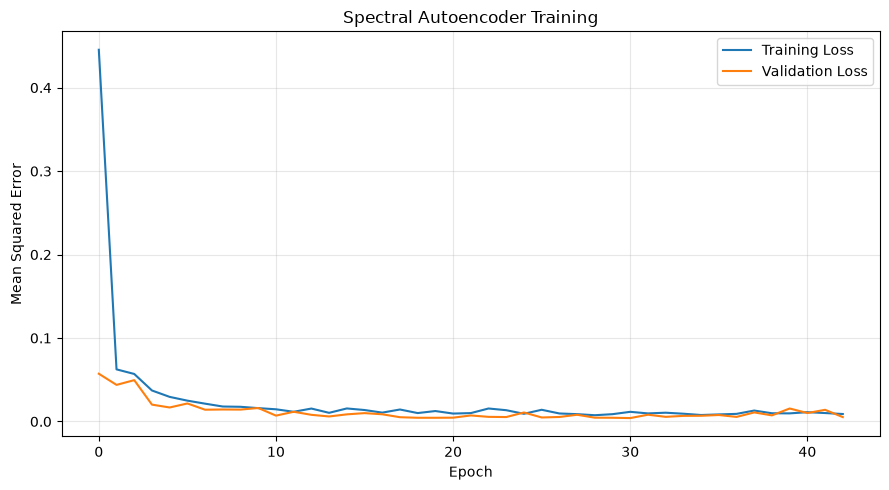

In [41]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    training_losses,
    label="Training Loss"
)

plt.plot(
    validation_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title(
    "Spectral Autoencoder Training"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
model.eval()

all_spectra_tensor = torch.tensor(
    X_scaled,
    dtype=torch.float32
).to(device)

with torch.no_grad():

    reconstructed_spectra = model(
        all_spectra_tensor
    )

reconstructed_spectra = (
    reconstructed_spectra
    .cpu()
    .numpy()
)

print(
    "Reconstructed spectra shape:",
    reconstructed_spectra.shape
)

Reconstructed spectra shape: (10000, 189)


In [45]:
reconstruction_errors = np.mean(
    (
        X_scaled
        - reconstructed_spectra
    ) ** 2,
    axis=1
)

print(
    "Minimum reconstruction error:",
    reconstruction_errors.min()
)

print(
    "Maximum reconstruction error:",
    reconstruction_errors.max()
)

print(
    "Mean reconstruction error:",
    reconstruction_errors.mean()
)

Minimum reconstruction error: 0.0005154934
Maximum reconstruction error: 0.111732565
Mean reconstruction error: 0.0041493815


In [47]:
autoencoder_anomaly_map = (
    reconstruction_errors.reshape(
        height,
        width
    )
)

print(
    "Anomaly map shape:",
    autoencoder_anomaly_map.shape
)

Anomaly map shape: (100, 100)


In [49]:
normalized_anomaly_map = (
    autoencoder_anomaly_map
    - autoencoder_anomaly_map.min()
) / (
    autoencoder_anomaly_map.max()
    - autoencoder_anomaly_map.min()
    + 1e-8
)

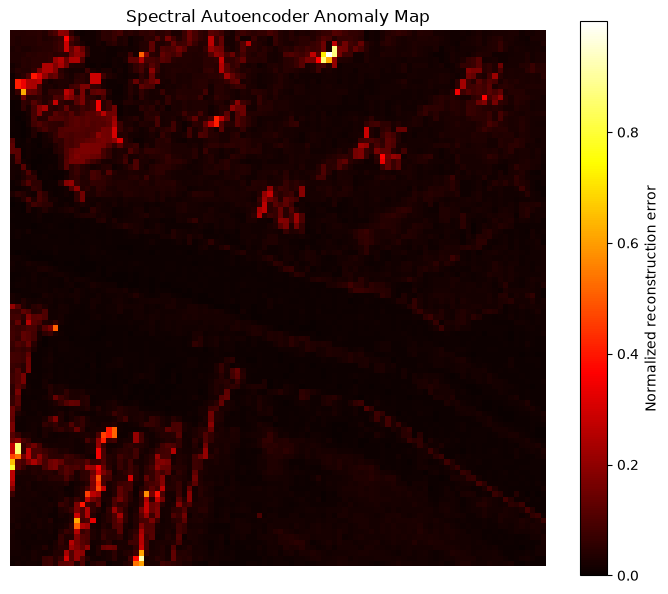

In [51]:
plt.figure(
    figsize=(7, 6)
)

plt.imshow(
    normalized_anomaly_map,
    cmap="hot"
)

plt.title(
    "Spectral Autoencoder Anomaly Map"
)

plt.colorbar(
    label="Normalized reconstruction error"
)

plt.axis("off")
plt.tight_layout()
plt.show()

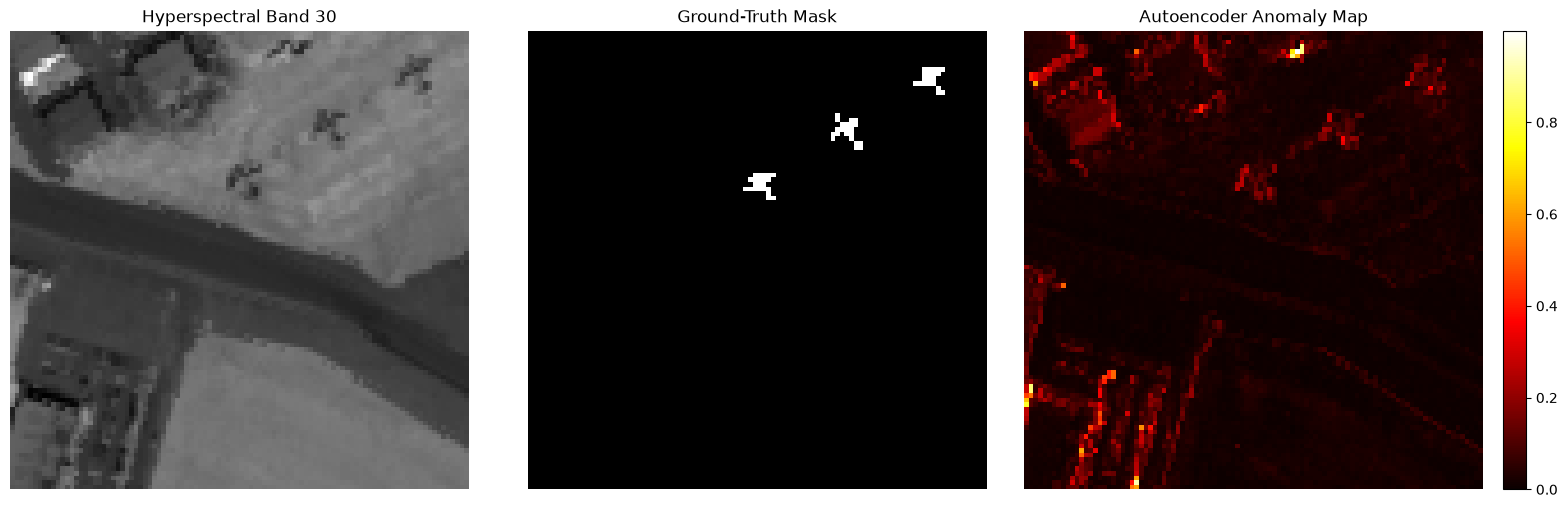

In [53]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5)
)

axes[0].imshow(
    cube[:, :, 30],
    cmap="gray"
)

axes[0].set_title(
    "Hyperspectral Band 30"
)

axes[0].axis("off")

axes[1].imshow(
    ground_truth,
    cmap="gray"
)

axes[1].set_title(
    "Ground-Truth Mask"
)

axes[1].axis("off")

image = axes[2].imshow(
    normalized_anomaly_map,
    cmap="hot"
)

axes[2].set_title(
    "Autoencoder Anomaly Map"
)

axes[2].axis("off")

figure.colorbar(
    image,
    ax=axes[2],
    fraction=0.046,
    pad=0.04
)

plt.tight_layout()
plt.show()

In [55]:
roc_auc = roc_auc_score(
    y,
    reconstruction_errors
)

pr_auc = average_precision_score(
    y,
    reconstruction_errors
)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

ROC-AUC: 0.9106
PR-AUC: 0.0346


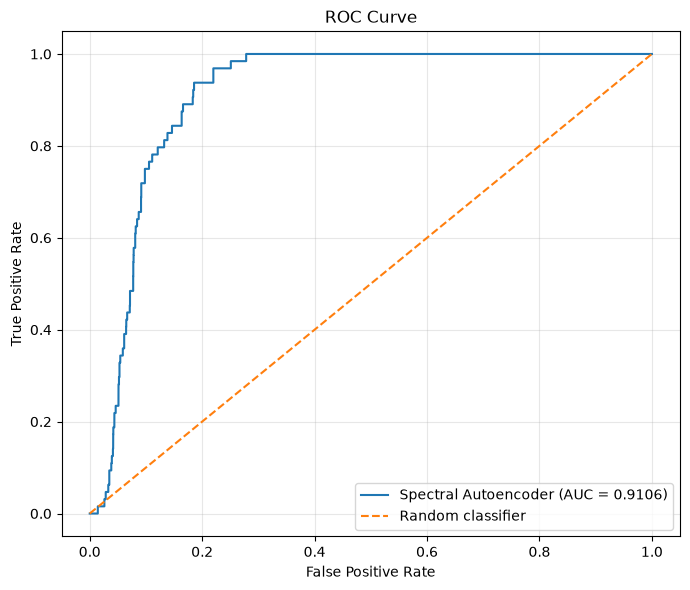

In [57]:
false_positive_rate, true_positive_rate, _ = roc_curve(
    y,
    reconstruction_errors
)

plt.figure(
    figsize=(7, 6)
)

plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=(
        f"Spectral Autoencoder "
        f"(AUC = {roc_auc:.4f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

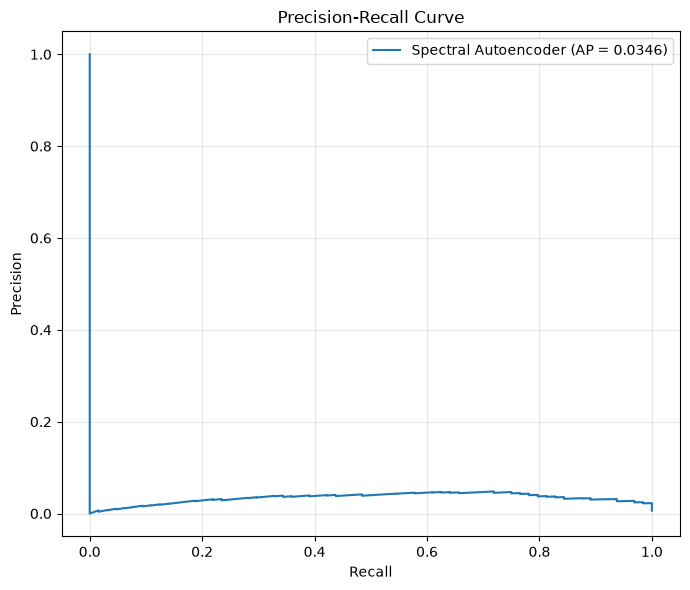

In [59]:
precision_values, recall_values, _ = precision_recall_curve(
    y,
    reconstruction_errors
)

plt.figure(
    figsize=(7, 6)
)

plt.plot(
    recall_values,
    precision_values,
    label=(
        f"Spectral Autoencoder "
        f"(AP = {pr_auc:.4f})"
    )
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    "Precision-Recall Curve"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [61]:
THRESHOLD_PERCENTILE = 99

threshold = np.percentile(
    reconstruction_errors,
    THRESHOLD_PERCENTILE
)

predicted_labels = (
    reconstruction_errors
    >= threshold
).astype(np.uint8)

predicted_mask = predicted_labels.reshape(
    height,
    width
)

print("Threshold:", threshold)
print(
    "Predicted anomaly pixels:",
    predicted_labels.sum()
)

Threshold: 0.029150367639958864
Predicted anomaly pixels: 100


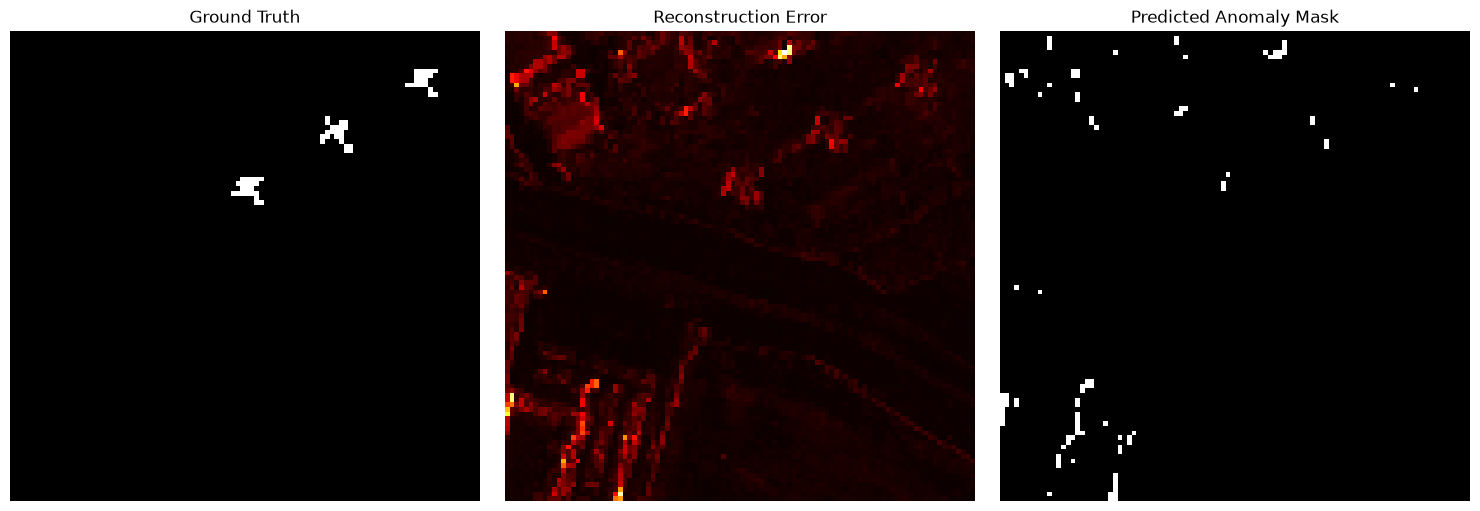

In [63]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

axes[0].imshow(
    ground_truth,
    cmap="gray"
)

axes[0].set_title(
    "Ground Truth"
)

axes[0].axis("off")

axes[1].imshow(
    normalized_anomaly_map,
    cmap="hot"
)

axes[1].set_title(
    "Reconstruction Error"
)

axes[1].axis("off")

axes[2].imshow(
    predicted_mask,
    cmap="gray"
)

axes[2].set_title(
    "Predicted Anomaly Mask"
)

axes[2].axis("off")

plt.tight_layout()
plt.show()

In [65]:
print(
    classification_report(
        y,
        predicted_labels,
        target_names=[
            "Background",
            "Anomaly"
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Background     0.9935    0.9899    0.9917      9936
     Anomaly     0.0000    0.0000    0.0000        64

    accuracy                         0.9836     10000
   macro avg     0.4968    0.4950    0.4959     10000
weighted avg     0.9872    0.9836    0.9854     10000



In [67]:
confusion_matrix_values = confusion_matrix(
    y,
    predicted_labels
)

confusion_matrix_table = pd.DataFrame(
    confusion_matrix_values,
    index=[
        "Actual Background",
        "Actual Anomaly"
    ],
    columns=[
        "Predicted Background",
        "Predicted Anomaly"
    ]
)

confusion_matrix_table

,Predicted Background,Predicted Anomaly
Actual Background,9836,100
Actual Anomaly,64,0


In [69]:
true_negative, false_positive, false_negative, true_positive = (
    confusion_matrix_values.ravel()
)

precision_score_value = (
    true_positive
    / (
        true_positive
        + false_positive
        + 1e-8
    )
)

recall_score_value = (
    true_positive
    / (
        true_positive
        + false_negative
        + 1e-8
    )
)

f1_score_value = (
    2
    * precision_score_value
    * recall_score_value
    / (
        precision_score_value
        + recall_score_value
        + 1e-8
    )
)

false_positive_rate_value = (
    false_positive
    / (
        false_positive
        + true_negative
        + 1e-8
    )
)

print("True positives:", true_positive)
print("False positives:", false_positive)
print("False negatives:", false_negative)
print("True negatives:", true_negative)

print(
    f"Precision: "
    f"{precision_score_value:.4f}"
)

print(
    f"Recall: "
    f"{recall_score_value:.4f}"
)

print(
    f"F1-score: "
    f"{f1_score_value:.4f}"
)

print(
    f"False-positive rate: "
    f"{false_positive_rate_value:.6f}"
)

True positives: 0
False positives: 100
False negatives: 64
True negatives: 9836
Precision: 0.0000
Recall: 0.0000
F1-score: 0.0000
False-positive rate: 0.010064


In [71]:
normal_errors = reconstruction_errors[
    y == 0
]

anomaly_errors = reconstruction_errors[
    y == 1
]

print(
    "Mean normal reconstruction error:",
    normal_errors.mean()
)

print(
    "Mean anomaly reconstruction error:",
    anomaly_errors.mean()
)

Mean normal reconstruction error: 0.004110277
Mean anomaly reconstruction error: 0.010220327


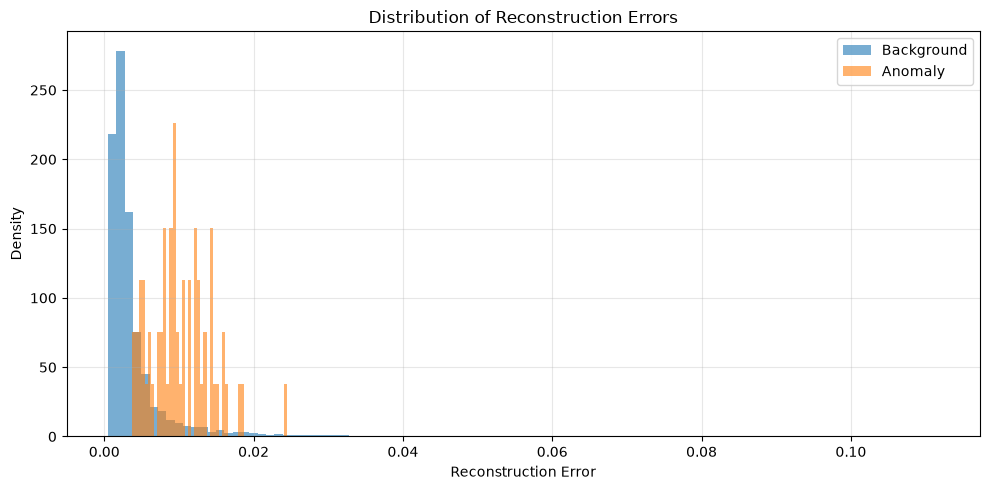

In [73]:
plt.figure(
    figsize=(10, 5)
)

plt.hist(
    normal_errors,
    bins=100,
    alpha=0.6,
    label="Background",
    density=True
)

plt.hist(
    anomaly_errors,
    bins=50,
    alpha=0.6,
    label="Anomaly",
    density=True
)

plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.title(
    "Distribution of Reconstruction Errors"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

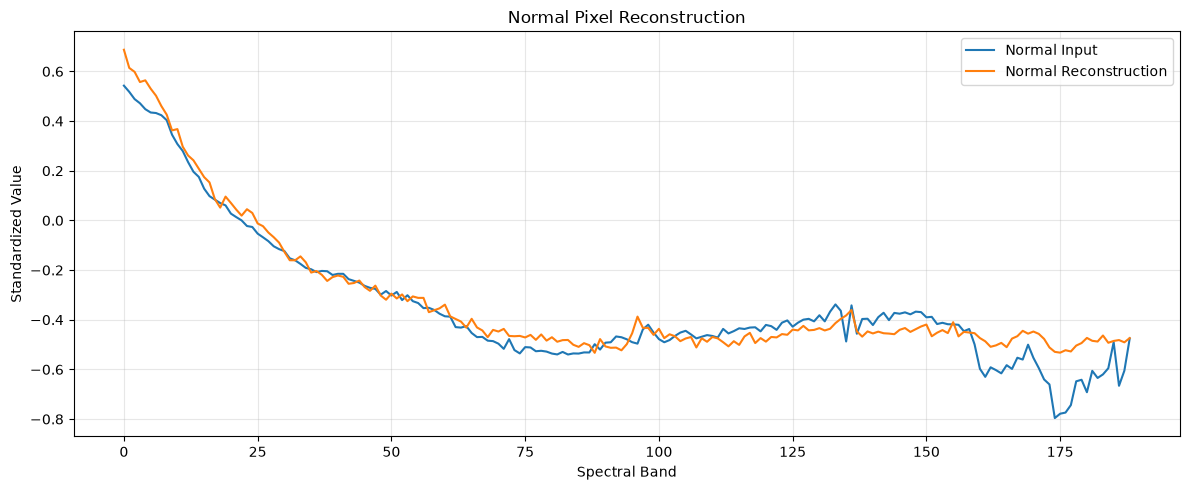

In [75]:
normal_pixel_index = np.where(
    y == 0
)[0][0]

anomaly_pixel_index = np.where(
    y == 1
)[0][0]

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    X_scaled[normal_pixel_index],
    label="Normal Input"
)

plt.plot(
    reconstructed_spectra[normal_pixel_index],
    label="Normal Reconstruction"
)

plt.xlabel("Spectral Band")
plt.ylabel("Standardized Value")
plt.title(
    "Normal Pixel Reconstruction"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

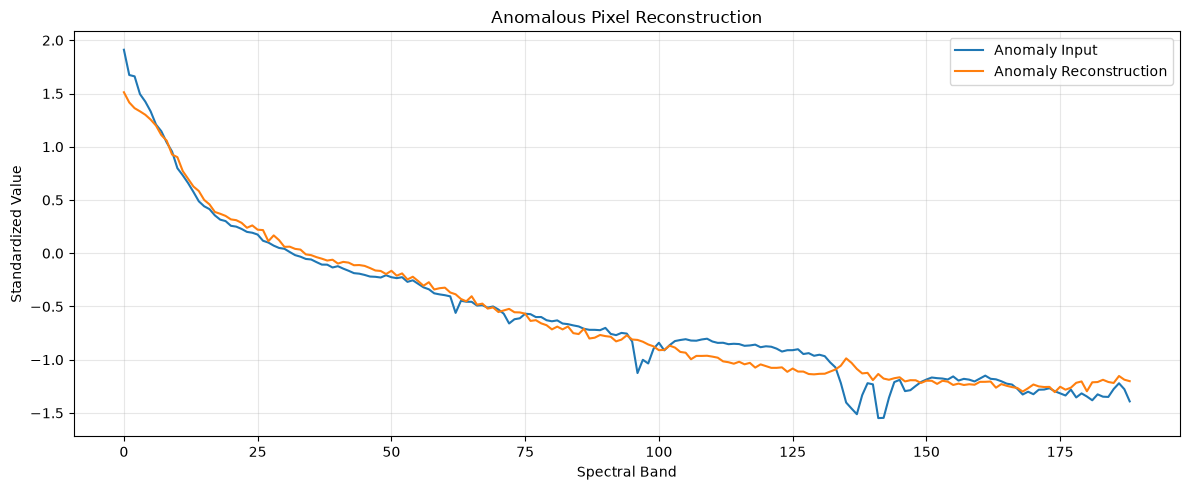

In [77]:
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    X_scaled[anomaly_pixel_index],
    label="Anomaly Input"
)

plt.plot(
    reconstructed_spectra[anomaly_pixel_index],
    label="Anomaly Reconstruction"
)

plt.xlabel("Spectral Band")
plt.ylabel("Standardized Value")
plt.title(
    "Anomalous Pixel Reconstruction"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [79]:
MODEL_PATH = os.path.join(
    MODELS_DIR,
    "spectral_dense_autoencoder.pt"
)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "number_of_bands": bands,
        "random_state": RANDOM_STATE
    },
    MODEL_PATH
)

print("Model saved to:", MODEL_PATH)

Model saved to: ../models/spectral_dense_autoencoder.pt


In [81]:
SCORE_PATH = os.path.join(
    RESULTS_DIR,
    "spectral_dense_autoencoder_scores.npy"
)

np.save(
    SCORE_PATH,
    autoencoder_anomaly_map
)

print("Anomaly scores saved to:", SCORE_PATH)

Anomaly scores saved to: ../results/spectral_dense_autoencoder_scores.npy


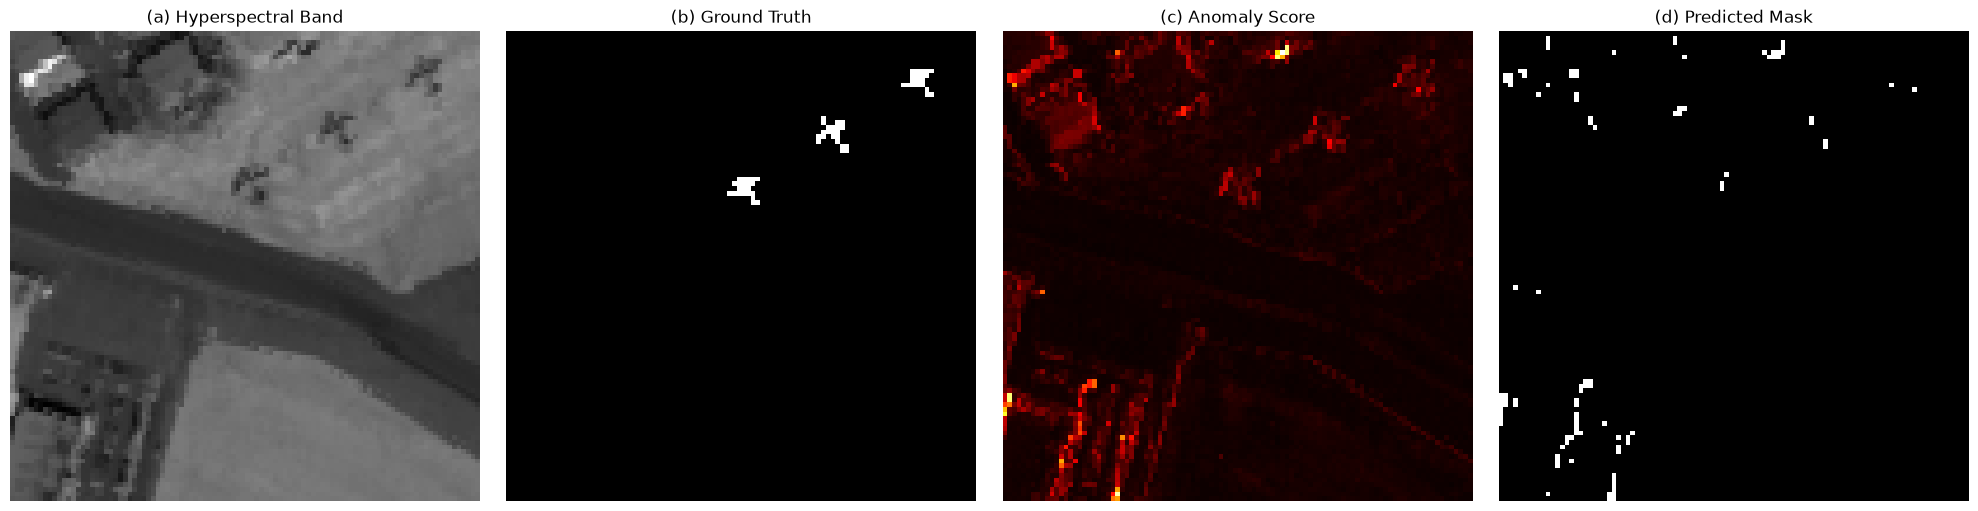

Figure saved to: ../results/spectral_dense_autoencoder_results.png


In [83]:
figure, axes = plt.subplots(
    1,
    4,
    figsize=(20, 5)
)

axes[0].imshow(
    cube[:, :, 30],
    cmap="gray"
)

axes[0].set_title(
    "(a) Hyperspectral Band"
)

axes[1].imshow(
    ground_truth,
    cmap="gray"
)

axes[1].set_title(
    "(b) Ground Truth"
)

axes[2].imshow(
    normalized_anomaly_map,
    cmap="hot"
)

axes[2].set_title(
    "(c) Anomaly Score"
)

axes[3].imshow(
    predicted_mask,
    cmap="gray"
)

axes[3].set_title(
    "(d) Predicted Mask"
)

for axis in axes:
    axis.axis("off")

plt.tight_layout()

FIGURE_PATH = os.path.join(
    RESULTS_DIR,
    "spectral_dense_autoencoder_results.png"
)

plt.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", FIGURE_PATH)

In [85]:
results_table = pd.DataFrame(
    {
        "Dataset": [
            "AVIRIS-1 San Diego"
        ],

        "Model": [
            "Spectral Dense Autoencoder"
        ],

        "ROC_AUC": [
            roc_auc
        ],

        "PR_AUC": [
            pr_auc
        ],

        "Threshold_Percentile": [
            THRESHOLD_PERCENTILE
        ],

        "Precision": [
            precision_score_value
        ],

        "Recall": [
            recall_score_value
        ],

        "F1": [
            f1_score_value
        ],

        "False_Positive_Rate": [
            false_positive_rate_value
        ],

        "Training_Time_Seconds": [
            training_time
        ],

        "Trainable_Parameters": [
            number_of_parameters
        ]
    }
)

results_table

,Dataset,Model,ROC_AUC,PR_AUC,Threshold_Percentile,Precision,Recall,F1,False_Positive_Rate,Training_Time_Seconds,Trainable_Parameters
0,AVIRIS-1 San Diego,Spectral Dense Autoencoder,0.910613,0.034627,99,0.0,0.0,0.0,0.010064,5.324368,69725


In [87]:
METRICS_PATH = os.path.join(
    RESULTS_DIR,
    "spectral_dense_autoencoder_metrics.csv"
)

results_table.to_csv(
    METRICS_PATH,
    index=False
)

print("Metrics saved to:", METRICS_PATH)

Metrics saved to: ../results/spectral_dense_autoencoder_metrics.csv


In [89]:
print("=" * 65)

print(
    "SPECTRAL DENSE AUTOENCODER "
    "EXPERIMENT SUMMARY"
)

print("=" * 65)

print(
    "Dataset: AVIRIS-1 San Diego"
)

print(
    "Cube shape:",
    cube.shape
)

print(
    "Model: Spectral Dense Autoencoder"
)

print(
    "Input bands:",
    bands
)

print(
    "Latent dimensions: 32"
)

print(
    "Trainable parameters:",
    number_of_parameters
)

print(
    f"Training time: "
    f"{training_time:.2f} seconds"
)

print(
    f"ROC-AUC: {roc_auc:.4f}"
)

print(
    f"PR-AUC: {pr_auc:.4f}"
)

print(
    f"Precision: "
    f"{precision_score_value:.4f}"
)

print(
    f"Recall: "
    f"{recall_score_value:.4f}"
)

print(
    f"F1-score: "
    f"{f1_score_value:.4f}"
)

print("=" * 65)

SPECTRAL DENSE AUTOENCODER EXPERIMENT SUMMARY
Dataset: AVIRIS-1 San Diego
Cube shape: (100, 100, 189)
Model: Spectral Dense Autoencoder
Input bands: 189
Latent dimensions: 32
Trainable parameters: 69725
Training time: 5.32 seconds
ROC-AUC: 0.9106
PR-AUC: 0.0346
Precision: 0.0000
Recall: 0.0000
F1-score: 0.0000
